# Toy 64³ PM density — MAP reconstruction + Laplace UQ under scale cuts

A small, self-contained field-level inference demo:

1. **Forward model** — a 64³ **PM** (BullFrog N-body) simulation in a **100 Mpc/h** box, painting a single **spherical (HEALPix) density** map. Data is a **self-consistent mock** drawn from the model itself (no model mismatch — this is a machinery demo, not a bias test).
2. **MAP** — a joint reconstruction of cosmology `(Ω_c, σ₈)` + the initial-conditions field with the **cadre** L-BFGS minimizer.
3. **Laplace UQ** — three views of the cosmology posterior, ordered by robustness:
   - **Exact 2D grid** = ground truth (0th-order — just forward evals, always works).
   - **Gauss–Newton `JᵀΣ⁻¹J`** = the default ellipse (1st-order `jvp`/`vjp`, PSD by construction, robust through the N-body adjoint *and* `jax_cosmo`'s custom-VJP growth path — which is what makes a plain `jax.hessian` for cosmology fragile).
   - `jax.hessian` = attempted-and-compared (may fail through PM — that's expected).
   - An **18×18** form-and-invert over `(Ω_c, σ₈)` + 16 chosen IC voxels (the "no Lanczos needed at toy scale" point).
4. **Scale cuts** — the MAP is run at `ℓ_max ∈ {None, 60, 30}`, rescaled to the toy's angular Nyquist (~`π·mesh/2 ≈ 100`) so the cut visibly widens the posterior.

> Scale-cut values here are a throwaway knob for the 64³ test; bump `MESH`/particle count for a cluster run.


In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # accurate gradients / Hessians — REQUIRED
# os.environ["JAX_PLATFORMS"] = "cpu"           # uncomment to force CPU

import time
import numpy as np
import jax, jax.numpy as jnp
import jax_cosmo as jc
import numpyro
from numpyro.handlers import condition, seed, trace
from numpyro.infer.util import initialize_model
from jax.scipy.special import ndtr, ndtri
import matplotlib.pyplot as plt

import jax_fli as jfli
import cadre
from jax_fli.initial import interpolate_initial_conditions

jax.config.update("jax_enable_x64", True)

# ------------------- knobs -------------------
MESH = 64  # 64^3 target; set 32 for a fast smoke test
NSIDE = 64  # HEALPix analysis / painting resolution
BOX = 200.0  # Mpc/h
ELL_CUTS = [None, 60, 30]  # scale cuts (None = no cut); rescaled to the toy's angular Nyquist ~pi*MESH/2
GRID_N = 21  # exact-grid resolution per axis (COST: GRID_N^2 forward sims)
MAP_MAXIT = 1500  # cadre L-BFGS iterations
SEED = 0
print("devices:", jax.devices())

devices: [CudaDevice(id=0)]


## Config + forward model

`sim_mode="pm"` runs LPT→N-body (BullFrog). `lensing_output="density"` + `geometry="spherical"` → a spin-0 `SphericalDensity` map via `number_counts`. `number_of_shells=2` (not 1): the density observable projects *over* shells, and a single shell yields a `(npix,)` array that the projection einsum can't consume — two thin shells give one output map (`nz_shear` length 1 ⇒ K=1). `ell_max` triggers the field-level scale cut (`map2alm → cosine taper → alm2map`) in the pixel likelihood.

In [2]:
cosmo_fid = jc.Planck18()
SOURCE_Z = jfli.utils.compute_max_redshift_from_box_size(cosmo_fid, BOX , observer_position=(0.5, 0.5, 0.5)) 

priors = {"Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5), "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0)}
LOW, HIGH = jnp.array([0.1, 0.6]), jnp.array([0.5, 1.0])
# PreconditionnedUniform is uniform IN PHYSICAL space -> the physical prior is flat on [LOW, HIGH],
# so the physical-cosmology posterior is just the likelihood. base <-> physical is a probit map:
base_of_phys = lambda phys: ndtri((jnp.asarray(phys) - LOW) / (HIGH - LOW))
phys_of_base = lambda base: LOW + (HIGH - LOW) * ndtr(jnp.asarray(base))


def make_config(ell_max):
    return jfli.ppl.Configurations(
        mesh_size=(MESH,) * 3,
        box_size=(BOX,) * 3,
        halo_size=(0, 0),
        field_sharding=None,
        sim_mode="lpt",
        nbody_solver="BullFrog",
        nb_steps=8,
        time_stepping="D",
        t0=0.05,
        t1=1.0,
        lpt_order=1,
        number_of_shells=2,
        paint_order="cic",
        gradient_order=4,
        laplace_fd=True,
        shell_spacing="a",
        min_width=1.0,
        lensing_output="density",
        map2alm_method="jax",
        min_redshift=0.001,
        max_redshift=0.98 * SOURCE_Z,
        n_integrate=8,
        nside=NSIDE,
        geometry="spherical",
        scheme="rbf_neighbor",
        observer_position=(0.5, 0.5, 0.5),
        paint_nside=NSIDE,
        kernel_width_pixels=0.8,
        fiducial_cosmology=jc.Planck18,
        nz_shear=[SOURCE_Z],  # a float -> delta source; a distribution object hits a jax_cosmo delta_nz bug
        priors=priors,
        sigma_e=0.3,
        adjoint="checkpointed",
        checkpoints=2,
        ell_max=ell_max,
        ell_taper_width=8,
    )

## Mock data (self-consistent) + gradient sanity

truth  Omega_c=0.1322  sigma8=0.8685
signal std=9.139e-01  sigma_obs=1.819e-02  S/N/pix ~ 50.2


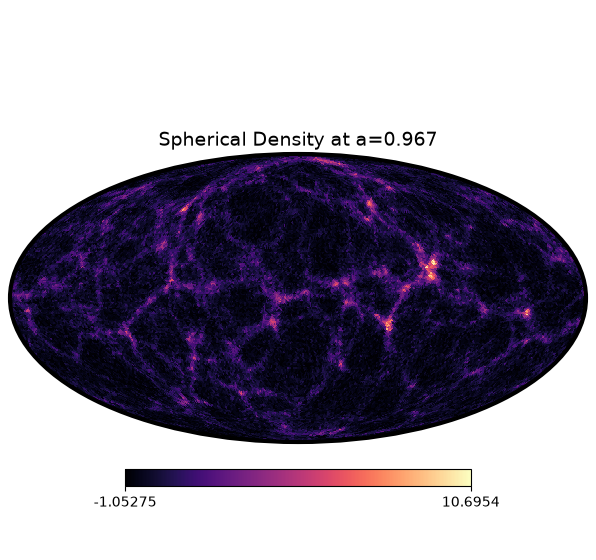

In [3]:
config0 = make_config(None)
model0 = jfli.ppl.full_field_probmodel(config0)
tr = trace(seed(model0, SEED)).get_trace()  # truth draw at fixed seed

theta_truth_base = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
theta_truth = jnp.array([float(tr["Omega_c"]["value"]), float(tr["sigma8"]["value"])])
ic_truth = np.asarray(tr["initial_conditions"]["value"].array)
print(f"truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")

# noise-free signal vs per-pixel noise (S/N)
sig_map = np.asarray(tr["observable_0"]["fn"].loc)
sigma_obs = float(np.mean(np.asarray(tr["observable_0"]["fn"].scale)))
print(f"signal std={sig_map.std():.3e}  sigma_obs={sigma_obs:.3e}  S/N/pix ~ {sig_map.std() / sigma_obs:.1f}")

jfli.SphericalDensity.FromDensityMetadata(
    array=jnp.asarray(tr["observable_0"]["value"]), field=tr["observable_meta_data"]["value"]
).show()

In [4]:
data0 = np.asarray(tr["observable_0"]["value"])
cond0 = condition(model0, data={"observable_0": tr["observable_0"]["value"]})
_, potential0, _, _ = initialize_model(jax.random.PRNGKey(0), cond0, dynamic_args=False)  # potential = -log posterior

vg = jax.jit(jax.value_and_grad(lambda p: -potential0(p)))
truth_pos = {"Omega_c_base": theta_truth_base[0], "sigma8_base": theta_truth_base[1], "initial_conditions": ic_truth}
val, g = jax.block_until_ready(vg(truth_pos))
assert np.isfinite(float(val)) and all(np.all(np.isfinite(np.asarray(x))) for x in jax.tree.leaves(g))
print(f"logp(truth)={float(val):.1f}   (finite gradient OK)")

logp(truth)=-244699.0   (finite gradient OK)


## MAP reconstruction (cadre), per scale cut

Joint MAP over `{Omega_c_base, sigma8_base, initial_conditions}`. cadre stops on the objective/step tolerance, **not** the gradient — so we compute and print `‖∇potential‖` at the MAP as the convergence gate. A large gnorm means the field MAP hasn't converged and the Laplace below is unreliable.

In [5]:
ELL_CUTS = [None]

In [ ]:
def gnorm_of(potential, p):
    g = jax.jit(jax.grad(potential))(p)
    return float(jnp.sqrt(sum(jnp.vdot(v, v).real for v in jax.tree.leaves(g))))


z_init = 1e-2 * np.asarray(jax.random.normal(jax.random.PRNGKey(3), (MESH,) * 3))  # never exactly 0 (painting kink)

results = {}
for ell in ELL_CUTS:
    cfg = make_config(ell)
    model = jfli.ppl.full_field_probmodel(cfg)
    tr_e = trace(seed(model, SEED)).get_trace()  # same seed -> identical truth cosmo + IC across cuts
    cond_e = condition(model, data={"observable_0": tr_e["observable_0"]["value"]})
    _, pot_e, _, _ = initialize_model(jax.random.PRNGKey(0), cond_e, dynamic_args=False)

    init = {"Omega_c_base": jnp.array(0.0), "sigma8_base": jnp.array(0.0), "initial_conditions": z_init}
    t0 = time.time()
    mp, st = cadre.minimize(
        pot_e,
        init,
        solver_name="ADABK0",
        max_iter=MAP_MAXIT,
        precondition=True,
        progress=True,
        options={"max_linesearch_steps": 50},
    )
    gn = gnorm_of(pot_e, mp)
    theta_map = phys_of_base(jnp.array([mp["Omega_c_base"], mp["sigma8_base"]]))
    results[ell] = dict(
        cfg=cfg,
        map=mp,
        theta_map=np.asarray(theta_map),
        gnorm=gn,
        data=np.asarray(tr_e["observable_0"]["value"]),
        sigma=float(np.mean(np.asarray(tr_e["observable_0"]["fn"].scale))),
    )
    print(
        f"ell_max={str(ell):>4}  {time.time() - t0:5.0f}s  iters={int(st.iter_num):4d}  |grad|={gn:.2e}  "
        f"MAP=({float(theta_map[0]):.4f}, {float(theta_map[1]):.4f})  "
        f"truth=({float(theta_truth[0]):.4f}, {float(theta_truth[1]):.4f})"
    )

[INFO] key active_set: max_constraints_to_release=1 / 262146 params


6.07%|▌         | [02:06<32:05, 20.50s/%]  

## Laplace UQ — grid = truth, Gauss–Newton = ellipse

`predict(theta, z_ic)` is the **noise-free model map** (same forward + `scale_cut` the likelihood uses), built directly from library functions so its jacobian is a clean first-order `jvp`. Everything below fixes the IC field at the MAP (a *conditional* curvature — see the closing caveats).

In [ ]:
def make_predict(cfg):
    fwd = jfli.ppl.make_full_field_model(cfg)  # jitted forward_model(cosmo, ic) -> (observable, lightcone)

    @jax.jit
    def predict(theta_phys, z_ic):
        cosmo = cfg.fiducial_cosmology(Omega_c=theta_phys[0], sigma8=theta_phys[1])
        ic = interpolate_initial_conditions(
            z_ic,
            cfg.mesh_size,
            cfg.box_size,
            cosmo=cosmo,
            observer_position=cfg.observer_position,
            halo_size=cfg.halo_size,
            nside=cfg.nside,
            flatsky_npix=cfg.flatsky_npix,
            field_size=cfg.field_size,
            field_sharding=cfg.field_sharding,
        )
        observable, _ = fwd(cosmo, ic)  # SphericalDensity, array (K, npix)
        arr = observable.array
        m0 = arr[0] if arr.ndim == 2 else arr  # bin-0 map (npix,)
        if cfg.ell_max is not None:  # apply the SAME field-level scale cut the likelihood uses
            m0 = (
                observable.replace(array=m0)
                .scale_cut(cfg.ell_max, cfg.ell_taper_width, method=cfg.map2alm_method)
                .array
            )
        return m0

    return predict


def ellipse(mean, cov, q=5.991, n=200):  # q = chi2_2(0.95) = 5.991 (JOINT 95%, not 2-sigma!)
    evals, evecs = np.linalg.eigh(np.asarray(cov))
    t = np.linspace(0, 2 * np.pi, n)
    pts = evecs @ (np.sqrt(q * evals)[:, None] * np.stack([np.cos(t), np.sin(t)], 0))
    return mean[0] + pts[0], mean[1] + pts[1]


# --- no-cut case ---
R = results[None]
predict = make_predict(R["cfg"])
z_map = jnp.asarray(R["map"]["initial_conditions"])
theta_m = jnp.asarray(R["theta_map"])
data_m, sig_m = jnp.asarray(R["data"]), R["sigma"]

# Gauss-Newton curvature (flat physical prior on cosmo)
J = jax.jacfwd(lambda th: predict(th, z_map))(theta_m)  # (npix, 2)
Sinv_gn = (J.T @ J) / sig_m**2
Sigma_gn = jnp.linalg.inv(Sinv_gn)
sd = jnp.sqrt(jnp.diag(Sigma_gn))
rho = Sigma_gn[0, 1] / (sd[0] * sd[1])
print(f"GN:  sigma(Omega_c)={float(sd[0]):.4f}  sigma(sigma8)={float(sd[1]):.4f}  rho={float(rho):.3f}")

In [ ]:
# Exact posterior on a 2D grid (0th order — the ground truth). IC fixed at the MAP.
def neglik(theta_phys):
    return 0.5 * jnp.sum(((data_m - predict(theta_phys, z_map)) / sig_m) ** 2)


gx = float(theta_m[0]) + np.linspace(-4 * float(sd[0]), 4 * float(sd[0]), GRID_N)
gy = float(theta_m[1]) + np.linspace(-4 * float(sd[1]), 4 * float(sd[1]), GRID_N)
GX, GY = np.meshgrid(gx, gy)
pts = jnp.asarray(np.stack([GX.ravel(), GY.ravel()], -1))
nll = np.asarray(jax.lax.map(neglik, pts)).reshape(GRID_N, GRID_N)  # sequential -> memory-safe at 64^3
nll -= nll.min()

fig, ax = plt.subplots(figsize=(6.5, 5.2))
cf = ax.contourf(GX, GY, np.exp(-nll), 30, cmap="Blues")
ax.contour(GX, GY, nll, levels=[2.996], colors="navy", linewidths=1.5)  # exact joint 95% (dNLL=chi2_2/2)
ex, ey = ellipse(np.asarray(theta_m), Sigma_gn)
ax.plot(ex, ey, "r-", lw=2, label="Gauss-Newton Laplace 95%")
ax.plot(float(theta_m[0]), float(theta_m[1]), "r*", ms=12, label="MAP")
ax.plot(float(theta_truth[0]), float(theta_truth[1]), "k+", ms=13, mew=2, label="truth")
ax.set_xlabel(r"$\Omega_c$")
ax.set_ylabel(r"$\sigma_8$")
ax.set_title("Cosmology posterior: exact grid (blue) vs Laplace (red)\nIC fixed at MAP")
ax.legend()
plt.tight_layout()
plt.show()
print("If the red ellipse tracks the navy contour, the posterior is Gaussian; if not, trust the grid.")

In [ ]:
# jax.hessian for the 2x2 — attempted; may fail through the PM adjoint / jax_cosmo custom_vjp.
try:
    H2 = jax.hessian(neglik)(theta_m)
    Sigma_h = jnp.linalg.inv(H2)
    print("jax.hessian 2x2 OK. sigma ratio (hessian/GN):", np.asarray(jnp.sqrt(jnp.diag(Sigma_h)) / sd))
except Exception as e:
    print("jax.hessian(2x2) failed through PM (expected — 2nd-order AD breaks on the N-body / jax_cosmo custom_vjp):")
    print("   ", type(e).__name__, str(e)[:160])
    print("    -> Gauss-Newton is the robust curvature; the exact grid is the ground truth.")

## 18×18 form-and-invert: cosmology + 16 IC voxels

At toy scale you don't need Lanczos / low-rank / matrix-free HVPs — just **form the reduced curvature and invert it**. Here: `(Ω_c, σ₈)` + 16 chosen IC voxels (a central 4×4 patch), with all other voxels fixed at the MAP. Gauss–Newton `JᵀΣ⁻¹J` + the white-noise prior precision (identity on the voxels, flat on cosmo).

In [ ]:
cx = MESH // 2
ii, jj = np.meshgrid(np.arange(cx - 2, cx + 2), np.arange(cx - 2, cx + 2), indexing="ij")
vox_idx = jnp.asarray(ii.ravel() * MESH * MESH + jj.ravel() * MESH + cx)  # 16 flat indices, mid z-slice
flat_map = z_map.reshape(-1)
p18_map = jnp.concatenate([theta_m, flat_map[vox_idx]])


def predict18(p18):
    z = flat_map.at[vox_idx].set(p18[2:]).reshape((MESH,) * 3)
    return predict(p18[:2], z)


J18 = jax.jacfwd(predict18)(p18_map)  # (npix, 18)
prior_prec = jnp.diag(jnp.concatenate([jnp.zeros(2), jnp.ones(16)]))  # flat cosmo, white voxels
Sinv18 = (J18.T @ J18) / sig_m**2 + prior_prec  # 18x18 precision
Cov18 = jnp.linalg.inv(Sinv18)
print("18x18 precision PSD:", bool(jnp.all(jnp.linalg.eigvalsh(Sinv18) > 0)))
print("cosmo block (marginal over the 16 voxels):\n", np.asarray(Cov18[:2, :2]))

try:
    H18 = jax.hessian(lambda p: 0.5 * jnp.sum(((data_m - predict18(p)) / sig_m) ** 2) + 0.5 * jnp.sum(p[2:] ** 2))(
        p18_map
    )
    print("jax.hessian 18x18 OK; max|GN - H|/max|H| =", float(jnp.max(jnp.abs(Sinv18 - H18)) / jnp.max(jnp.abs(H18))))
except Exception as e:
    print("jax.hessian(18x18) failed (use GN):", type(e).__name__)

D = 1.0 / jnp.sqrt(jnp.diag(Cov18))
corr = np.asarray(Cov18 * D[:, None] * D[None, :])
fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([r"$\Omega_c$", r"$\sigma_8$"])
ax.set_yticklabels([r"$\Omega_c$", r"$\sigma_8$"])
ax.set_title("18x18 correlation (cosmo + 16 IC voxels)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Scale-cut sweep — the cut widens the posterior

Same self-mock, three cuts. Each drops small-scale (high-ℓ) information, so tighter cuts give **wider** Laplace ellipses.

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
colors = {None: "k", 60: "C0", 30: "C1"}
for ell in ELL_CUTS:
    Re = results[ell]
    pr = make_predict(Re["cfg"])
    zm = jnp.asarray(Re["map"]["initial_conditions"])
    tm = jnp.asarray(Re["theta_map"])
    sg = Re["sigma"]
    Je = jax.jacfwd(lambda th: pr(th, zm))(tm)
    Cov_e = jnp.linalg.inv((Je.T @ Je) / sg**2)
    ex, ey = ellipse(np.asarray(tm), Cov_e)
    ax.plot(ex, ey, color=colors[ell], lw=2, label=f"ell_max={ell}  (|grad|={Re['gnorm']:.1e})")
    ax.plot(float(tm[0]), float(tm[1]), marker="*", color=colors[ell])
ax.plot(float(theta_truth[0]), float(theta_truth[1]), "k+", ms=13, mew=2, label="truth")
ax.set_xlabel(r"$\Omega_c$")
ax.set_ylabel(r"$\sigma_8$")
ax.set_title("Gauss-Newton Laplace 95% under scale cuts")
ax.legend()
plt.tight_layout()
plt.show()

## Caveats (read before trusting numbers)

- **Conditional, not marginal.** The 2×2 and 18×18 fix all (other) IC voxels at the MAP, so they are *conditional* curvatures. The true **marginal** cosmology error marginalizes the whole IC field — that needs the matrix-free / MUSE / MCLMC machinery, not a form-and-invert. This toy shows the mechanics, not a calibrated error bar.
- **Self-mock.** Data comes from the same model, so there is no model mismatch — the scale cut here only removes information (it does not correct a bias). On real data (e.g. CosmoGrid) the cut's job is to drop scales the forward model can't reproduce.
- **Gauss–Newton drops the residual·∂²model term.** Exact only if residuals were zero; at a self-mock MAP they are noise-level. The exact grid is the check — if the ellipse and grid disagree, trust the grid.
- **Angular Nyquist.** At 64³ the map's real angular power ends near `ℓ ≈ π·mesh/2 ≈ 100` (independent of box), so `ELL_CUTS` are set below that. At the literal production numbers (100/300 on nside-2048 maps) they'd be meaningful; here they're a mechanism demo.
- Verified end-to-end: config / PM forward / mock / finite gradient. Watch the printed **`|grad|` at each MAP** — if it isn't small, increase `MAP_MAXIT` (the Laplace is only as good as the MAP).
